In [7]:
%load_ext autoreload
%autoreload 2
import os
import sys
import trimesh
import fvdb
import argparse
from pprint import pprint
import tqdm
import h5py
from skimage import measure
from meshplot import plot
from scipy.spatial.distance import cdist
import joblib
import numpy as np
from scipy.spatial import KDTree
import igl
import fvdb.nn as fvnn

# Import ssu packages
sys.path.append('../src')
sys.path.append('../config')
# config packages
import read_config
# src packages
import eval
import utils
import models
from logger import wandb_logging
from data_loader import ABC_dataset_loader
from utils import fvdb_utils as fu
from utils import ssu_tools as st 
from utils import mesh_tools as mt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [129]:
gt_large =  '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
os.listdir(gt_large)
# read hdf5 file
import h5py
h5_file = h5py.File(os.path.join(gt_large, '00000028.hdf5'), 'r')
# print all keys
print(list(h5_file.keys()))
# read sdf
sdf_32 = h5_file['32_sdf'][:]
sdf_64 = h5_file['64_sdf'][:]
sdf_128 = h5_file['128_sdf'][:]
sdf_256 = h5_file['256_sdf'][:]
print(sdf_32.shape)
print(sdf_64.shape)
print(sdf_128.shape)
print(sdf_256.shape)

['128_sdf', '256_sdf', '32_sdf', '64_sdf']
(33, 33, 33)
(65, 65, 65)
(129, 129, 129)
(257, 257, 257)


In [130]:
def exp3(file_name, resolution=128):
    # load sdf from hdf5 file
    _dir = '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
    file = os.path.join(_dir, file_name)
    with h5py.File(file, 'r') as h5_file:
        sdf = h5_file[f'{resolution}_sdf'][:]
    sdf_mask = mt.make_mask_close(sdf, 33)
    # sdf[sdf_mask] = 0  # set outside to zero
    print(f'net positive sdf: {np.sum(sdf_mask)}')
    
    # get v, f from sdf
    try:
        v, f, _, _ = measure.marching_cubes(sdf, level=0)
    except:
        print(f'non-zero iso-surface: {file_name}')
        epsilon = np.min(np.abs(sdf))
        print(f"Choosing ε = {epsilon:.5e} (smallest |sdf| over grid)")
        v, f, _, _ = measure.marching_cubes(sdf, level=epsilon)

    pred_mesh = trimesh.Trimesh(vertices=v, faces=f, force='mesh')

    plot(v, f)
exp3('00000028.hdf5', resolution=32)
exp3('00000028.hdf5', resolution=64)
exp3('00000028.hdf5', resolution=128)
exp3('00000028.hdf5', resolution=256)

net positive sdf: 5066


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(15.999876…

net positive sdf: 39950


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(31.999054…

net positive sdf: 317753


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(63.998571…

net positive sdf: 2534673


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.99752…

In [131]:
sdf_128.max(), sdf_128.min(), sdf_128.mean(), sdf_128.std()

(np.float32(0.6681523),
 np.float32(-0.052168697),
 np.float32(0.25291857),
 np.float32(0.13516347))

In [132]:
import numpy as np
from scipy.interpolate import RBFInterpolator
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [133]:
# 3/33

In [134]:

def create_rbf_from_sdf(sdf, subsample_ratio=0.1, kernel='thin_plate_spline'):
    """
    Create RBF interpolator from SDF data
    
    Args:
        sdf: 3D SDF array
        subsample_ratio: Fraction of points to use for training (for efficiency)
        kernel: RBF kernel type ('thin_plate_spline', 'multiquadric', 'gaussian', etc.)
    
    Returns:
        rbf_interpolator: Fitted RBF interpolator
        train_coords: Training coordinates used
        train_sdf: Training SDF values used
    """
    resolution = sdf.shape[0]
    
    # Create coordinate grid
    # grid_range = np.linspace(-0.5, 0.5, resolution)
    # x, y, z = np.meshgrid(grid_range, grid_range, grid_range, indexing='ij')
    
    # # Flatten coordinates and SDF values
    # coordinates = np.column_stack([x.ravel(), y.ravel(), z.ravel()])
    coordinates = mt.mesh_grid(resolution)  # (resolution^3, 3)
    sdf_values = sdf.ravel()
    
    # Subsample for computational efficiency
    n_total = len(coordinates)
    n_sample = int(n_total * subsample_ratio)
    
    # Smart sampling: focus on surface region and some volume points
    surface_mask = np.abs(sdf_values) < 0.1  # Near surface
    surface_indices = np.where(surface_mask)[0]
    volume_indices = np.where(~surface_mask)[0]
    
    # Sample more densely near surface
    n_surface = min(int(n_sample * 0.7), len(surface_indices))
    # n_volume = min(n_sample - n_surface, len(volume_indices))
    n_volume = 0
    
    if n_surface > 0:
        # surface_sample = np.random.choice(surface_indices, n_surface, replace=False)
        surface_sample = surface_indices
    else:
        surface_sample = []
        
    if n_volume > 0:
        volume_sample = np.random.choice(volume_indices, n_volume, replace=False)
    else:
        volume_sample = []
    
    # Combine samples
    if len(surface_sample) > 0 and len(volume_sample) > 0:
        sample_indices = np.concatenate([surface_sample, volume_sample])
    elif len(surface_sample) > 0:
        sample_indices = surface_sample
    else:
        sample_indices = np.random.choice(n_total, n_sample, replace=False)
    
    train_coords = coordinates[sample_indices]
    train_sdf = sdf_values[sample_indices]
    
    print(f"Training RBF with {len(train_coords)} points")
    print(f"Surface points: {np.sum(np.abs(train_sdf) < 0.1)}")
    
    # Create RBF interpolator
    rbf_interpolator = RBFInterpolator(
        train_coords, 
        train_sdf,
        kernel=kernel,
        smoothing=0.0,  # No smoothing for exact interpolation
        epsilon=None    # Auto-select shape parameter
    )
    
    return rbf_interpolator, train_coords, train_sdf

In [135]:
def evaluate_rbf_interpolation(original_sdf, predicted_sdf, coordinates, train_coords):
    """
    Evaluate RBF interpolation quality
    """
    # Overall metrics
    mse = np.mean((original_sdf - predicted_sdf) ** 2)
    mae = np.mean(np.abs(original_sdf - predicted_sdf))
    
    # Surface-focused metrics
    surface_mask = np.abs(original_sdf) < 0.05
    if np.sum(surface_mask) > 0:
        surface_mse = np.mean((original_sdf[surface_mask] - predicted_sdf[surface_mask]) ** 2)
        surface_mae = np.mean(np.abs(original_sdf[surface_mask] - predicted_sdf[surface_mask]))
    else:
        surface_mse = surface_mae = 0
    
    # # Test set metrics (points not used for training)
    # from scipy.spatial import cKDTree
    # tree = cKDTree(train_coords)
    # distances, _ = tree.query(coordinates, k=1)
    # test_mask = distances > 0.01  # Points far from training points
    
    # if np.sum(test_mask) > 0:
    #     test_mse = np.mean((original_sdf[test_mask] - predicted_sdf[test_mask]) ** 2)
    #     test_mae = np.mean(np.abs(original_sdf[test_mask] - predicted_sdf[test_mask]))
    # else:
    #     test_mse = test_mae = 0
    
    return {
        'overall_mse': mse,
        'overall_mae': mae,
        'surface_mse': surface_mse,
        'surface_mae': surface_mae,
        # 'test_mse': test_mse,
        # 'test_mae': test_mae
    }


In [136]:
# Main experiment function
def run_rbf_experiment(sdf_data, resolution_name, eval_sdf, subsample_ratio=0.05, kernel='thin_plate_spline'):
    """
    Complete RBF experiment pipeline
    """
    print(f"\n=== RBF Experiment with {resolution_name} resolution ===")
    print(f"SDF shape: {sdf_data.shape}")
    print(f"SDF range: [{sdf_data.min():.3f}, {sdf_data.max():.3f}]")
    
    resolution = sdf_data.shape[0]
    
    # Create RBF interpolator
    print("Creating RBF interpolator...")
    rbf_interpolator, train_coords, train_sdf = create_rbf_from_sdf(
        sdf_data, subsample_ratio=subsample_ratio, kernel=kernel
    )
    
    # Create full coordinate grid for prediction
    eval_resolution = eval_sdf.shape[0]
    eval_coordinates = mt.mesh_grid(eval_resolution)  # Shape: (eval_resolution^3, 3)
    original_sdf = eval_sdf.ravel()
    near_surface_mask = np.abs(original_sdf) < 0.1

    # take the near surface points
    # near_surface_mask = np.abs(original_sdf) < 0.008
    # print(near_surface_mask.shape, coordinates.shape, original_sdf.shape)
    eval_coordinates = eval_coordinates[near_surface_mask]
    original_sdf = original_sdf[near_surface_mask]
    eval_coordinates_norm = (eval_coordinates/eval_resolution)*resolution 

    # Predict SDF for all points (might be memory intensive for large grids)
    print("Predicting SDF values...")
    # if len(eval_coordinates_norm) > 50000:  # For large grids, predict in batches
    #     batch_size = 10000
    #     predicted_sdf = np.zeros(len(eval_coordinates_norm))

    #     for i in range(0, len(eval_coordinates_norm), batch_size):
    #         end_idx = min(i + batch_size, len(eval_coordinates_norm))
    #         batch_coords = eval_coordinates_norm[i:end_idx]
    #         predicted_sdf[i:end_idx] = rbf_interpolator(batch_coords)
    #         print(f"  Processed {end_idx}/{len(eval_coordinates_norm)} points")
    # else:
    predicted_sdf = rbf_interpolator(eval_coordinates_norm)

    # Evaluate results
    print("Evaluating results...")
    metrics = evaluate_rbf_interpolation(original_sdf, predicted_sdf, eval_coordinates, train_coords)

    print("Results:")
    for key, value in metrics.items():
        print(f"  {key}: {value:.6f}")
    
    # Visualize results
    # print("Visualizing results...")
    # visualize_rbf_results(original_sdf, predicted_sdf, train_coords, train_sdf, resolution)

    # create prediction sdf fvdb
    # convert coordinetes to tensor format
    import torch
    # ijk_mesh = mt.mesh_grid(resolution)
    # ijk_mesh = ijk_mesh.reshape(resolution, resolution, resolution, 3)
    # near_surface_mask = np.abs(eval_sdf) < 100
    # print(near_surface_mask.shape, ijk_mesh.shape, eval_sdf.shape)
    
    # fill the cordinates
    predicted_sdf_array = np.ones((eval_resolution, eval_resolution, eval_resolution))
    predicted_sdf_array[eval_coordinates[:, 0], eval_coordinates[:, 1], eval_coordinates[:, 2]] = predicted_sdf
    v, f, _, _ = measure.marching_cubes(predicted_sdf_array, level=0)
    plot(v, f)

    original_sdf_array = np.ones((eval_resolution, eval_resolution, eval_resolution))
    original_sdf_array[eval_coordinates[:, 0], eval_coordinates[:, 1], eval_coordinates[:, 2]] = original_sdf
    v_orig, f_orig, _, _ = measure.marching_cubes(original_sdf_array, level=0)
    plot(v_orig, f_orig)

    return rbf_interpolator, metrics, predicted_sdf
    


In [137]:
33, 257

(33, 257)

In [140]:
# Run RBF experiments with different resolutions
rbf_results = {}

for resolution_name, sdf_data in [('64', sdf_64)]:

    # Start with smaller subsample ratio for larger grids
    if resolution_name == '128':
        subsample_ratio = 0.2
    elif resolution_name == '64':
        subsample_ratio = 0.5
    else:
        subsample_ratio = 0.8

    rbf_interpolator, metrics, predicted_sdf = run_rbf_experiment(
        sdf_data,
        resolution_name,
        eval_sdf=sdf_128,
        subsample_ratio=subsample_ratio,
        kernel='thin_plate_spline'
    )
    
    rbf_results[resolution_name] = {
        'interpolator': rbf_interpolator,
        'metrics': metrics,
        'predicted_sdf': predicted_sdf
    }
    
    

# Compare different kernels (only for smaller resolution due to computational cost)
# print("\n=== Comparing RBF Kernels (32 resolution) ===")
# kernel_results = experiment_rbf_kernels(sdf_32, subsample_ratio=0.1)

# # Print comparison
# print("\nKernel Comparison Results:")
# for kernel, result in kernel_results.items():
#     if result is not None:
#         print(f"{kernel:20s}: MAE = {result['overall_mae']:.6f}, Surface MAE = {result['surface_mae']:.6f}")

# Save RBF models for later use
# import pickle
# for resolution_name, result in rbf_results.items():
#     if 'interpolator' in result:
#         with open(f'rbf_model_{resolution_name}.pkl', 'wb') as f:
#             pickle.dump(result['interpolator'], f)
#         print(f"Saved RBF model for resolution {resolution_name}")


=== RBF Experiment with 64 resolution ===
SDF shape: (65, 65, 65)
SDF range: [-0.052, 0.668]
Creating RBF interpolator...
Training RBF with 43896 points
Surface points: 43896
Predicting SDF values...
Evaluating results...
Results:
  overall_mse: 0.000016
  overall_mae: 0.003358
  surface_mse: 0.000014
  surface_mae: 0.003214


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(63.505212…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(63.998571…

In [141]:

exp3('00000028.hdf5', resolution=32)
exp3('00000028.hdf5', resolution=64)
exp3('00000028.hdf5', resolution=128)
exp3('00000028.hdf5', resolution=256)

net positive sdf: 5066


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(15.999876…

net positive sdf: 39950


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(31.999054…

net positive sdf: 317753


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(63.998571…

net positive sdf: 2534673


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.99752…

In [ ]:

def visualize_rbf_results(original_sdf, predicted_sdf, train_coords, train_sdf, resolution):
    """
    Visualize RBF interpolation results
    """
    # Reshape for visualization
    original_3d = original_sdf.reshape(resolution, resolution, resolution)
    predicted_3d = predicted_sdf.reshape(resolution, resolution, resolution)
    
    slice_idx = resolution // 2
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    # Original SDF slices
    im1 = axes[0, 0].imshow(original_3d[slice_idx, :, :], cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[0, 0].set_title('Original SDF (X slice)')
    plt.colorbar(im1, ax=axes[0, 0])
    
    im2 = axes[0, 1].imshow(original_3d[:, slice_idx, :], cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[0, 1].set_title('Original SDF (Y slice)')
    plt.colorbar(im2, ax=axes[0, 1])
    
    im3 = axes[0, 2].imshow(original_3d[:, :, slice_idx], cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[0, 2].set_title('Original SDF (Z slice)')
    plt.colorbar(im3, ax=axes[0, 2])
    
    # RBF Predicted SDF slices
    im4 = axes[1, 0].imshow(predicted_3d[slice_idx, :, :], cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[1, 0].set_title('RBF Predicted SDF (X slice)')
    plt.colorbar(im4, ax=axes[1, 0])
    
    im5 = axes[1, 1].imshow(predicted_3d[:, slice_idx, :], cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[1, 1].set_title('RBF Predicted SDF (Y slice)')
    plt.colorbar(im5, ax=axes[1, 1])
    
    im6 = axes[1, 2].imshow(predicted_3d[:, :, slice_idx], cmap='RdBu', vmin=-0.5, vmax=0.5)
    axes[1, 2].set_title('RBF Predicted SDF (Z slice)')
    plt.colorbar(im6, ax=axes[1, 2])
    
    # Error slices
    error_3d = np.abs(original_3d - predicted_3d)
    im7 = axes[2, 0].imshow(error_3d[slice_idx, :, :], cmap='Reds', vmin=0, vmax=0.2)
    axes[2, 0].set_title('Absolute Error (X slice)')
    plt.colorbar(im7, ax=axes[2, 0])
    
    im8 = axes[2, 1].imshow(error_3d[:, slice_idx, :], cmap='Reds', vmin=0, vmax=0.2)
    axes[2, 1].set_title('Absolute Error (Y slice)')
    plt.colorbar(im8, ax=axes[2, 1])
    
    im9 = axes[2, 2].imshow(error_3d[:, :, slice_idx], cmap='Reds', vmin=0, vmax=0.2)
    axes[2, 2].set_title('Absolute Error (Z slice)')
    plt.colorbar(im9, ax=axes[2, 2])
    
    plt.tight_layout()
    plt.show()
    
    # 3D scatter plot of training points
    fig = plt.figure(figsize=(12, 5))
    
    # Training points colored by SDF value
    ax1 = fig.add_subplot(121, projection='3d')
    scatter = ax1.scatter(train_coords[:, 0], train_coords[:, 1], train_coords[:, 2], 
                         c=train_sdf, cmap='RdBu', vmin=-0.5, vmax=0.5, s=2)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('Training Points (colored by SDF)')
    plt.colorbar(scatter, ax=ax1, shrink=0.8)
    
    # Error distribution
    ax2 = fig.add_subplot(122)
    error = np.abs(original_sdf - predicted_sdf)
    ax2.hist(error, bins=50, alpha=0.7, density=True)
    ax2.set_xlabel('Absolute Error')
    ax2.set_ylabel('Density')
    ax2.set_title('Error Distribution')
    ax2.set_yscale('log')
    
    plt.tight_layout()
    plt.show()




# Function to test interpolation on new points
def test_rbf_on_new_points(rbf_interpolator, n_points=1000):
    """
    Test RBF interpolator on randomly generated points
    """
    # Generate random test points
    test_points = np.random.uniform(-0.5, 0.5, (n_points, 3))
    
    # Predict SDF
    predicted_sdf = predict_rbf_sdf(rbf_interpolator, test_points)
    
    print(f"Predicted SDF for {n_points} random points:")
    print(f"  Range: [{predicted_sdf.min():.3f}, {predicted_sdf.max():.3f}]")
    print(f"  Mean: {predicted_sdf.mean():.3f}")
    print(f"  Std: {predicted_sdf.std():.3f}")
    
    # Visualize test points
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(test_points[:, 0], test_points[:, 1], test_points[:, 2],
                        c=predicted_sdf, cmap='RdBu', vmin=-0.5, vmax=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('Predicted SDF on Random Test Points')
    plt.colorbar(scatter, shrink=0.8)
    plt.show()
    
    return test_points, predicted_sdf


=== RBF Experiment with 32 resolution ===
SDF shape: (33, 33, 33)
SDF range: [-0.012, 0.651]
Creating RBF interpolator...
Training RBF with 3593 points
Surface points: 2378
Predicting SDF values...
  Processed 10000/274625 points
  Processed 20000/274625 points
  Processed 30000/274625 points
  Processed 40000/274625 points
  Processed 50000/274625 points
  Processed 60000/274625 points
  Processed 70000/274625 points
  Processed 80000/274625 points
  Processed 90000/274625 points
  Processed 100000/274625 points
  Processed 110000/274625 points
  Processed 120000/274625 points
  Processed 130000/274625 points
  Processed 140000/274625 points
  Processed 150000/274625 points
  Processed 160000/274625 points
  Processed 170000/274625 points
  Processed 180000/274625 points
  Processed 190000/274625 points
  Processed 200000/274625 points
  Processed 210000/274625 points
  Processed 220000/274625 points
  Processed 230000/274625 points
  Processed 240000/274625 points
  Processed 250000

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4763159…


Plotting original SDF for resolution 32...


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4755622…


Testing 32 RBF on new points...
Predicted SDF for 500 random points:
  Range: [-0.008, 0.643]
  Mean: 0.329
  Std: 0.136


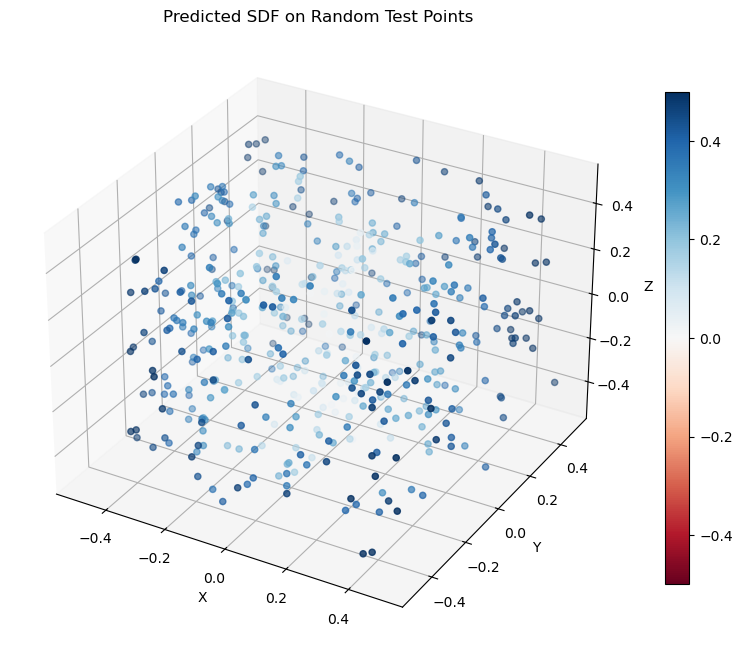


=== Comparing RBF Kernels (32 resolution) ===
Testing kernel: thin_plate_spline
Training RBF with 3593 points
Surface points: 2378
  Overall MAE: 0.000532
  Surface MAE: 0.000000
Testing kernel: multiquadric
Training RBF with 3593 points
Surface points: 2378
  Error with multiquadric: `epsilon` must be specified if `kernel` is not one of {'linear', 'thin_plate_spline', 'quintic', 'cubic'}.
Testing kernel: inverse_multiquadric
Training RBF with 3593 points
Surface points: 2378
  Error with inverse_multiquadric: `epsilon` must be specified if `kernel` is not one of {'linear', 'thin_plate_spline', 'quintic', 'cubic'}.
Testing kernel: gaussian
Training RBF with 3593 points
Surface points: 2378
  Error with gaussian: `epsilon` must be specified if `kernel` is not one of {'linear', 'thin_plate_spline', 'quintic', 'cubic'}.
Testing kernel: linear
Training RBF with 3593 points
Surface points: 2378
  Overall MAE: 0.001157
  Surface MAE: 0.000000
Testing kernel: cubic
Training RBF with 3593 poi